# Group Comparisons with new parameter settings (tan-HYPERBOLICUS, kernel & z-trans)



In [2]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt
import seaborn as sns

from utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

dataset ='dnumrisk' #'smile1'#
bids_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-{dataset}'
subList = [f'{int(sub):02d}' for sub in range(1, 67)]

target_folder = op.join(bids_folder,'derivatives','gradients.tryParams.36P')

In [12]:
alignRef = 'tanH'
kernel ='normalized_angle' #  None #
ztransf = False
specification = f'kernel-{kernel}_ztransf-{ztransf}'

n_gradients = 3
gms_aligned = {f'g{i+1}': [] for i in range(n_gradients)}
for sub in subList:
    source_folder_gm =  op.join(target_folder,f'sub-{sub}')
    fn = op.join(source_folder_gm,f'sub-{sub}_g-aligned-{alignRef}_{specification}.npy')

    gm_aligned = np.load(fn)
    for i in range(n_gradients):
        gms_aligned[f'g{i+1}'].append(gm_aligned[i, :])

sub_array = np.array([int(i) for i in subList])

In [13]:
# add group info
bids_folder_orig = '/mnt_03/ds-dnumrisk' 
df_participants = pd.read_csv(op.join(bids_folder_orig, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
group_list = group_list#.reset_index()

dfs = []
for i in range(n_gradients):
    gradient_df = pd.DataFrame(gms_aligned[f'g{i+1}'], index=sub_array)
    gradient_df.index.name = 'subject'
    gradient_df = gradient_df.join(group_list).set_index('group', append=True)
    gradient_df['n_gradient'] = i + 1
    dfs.append(gradient_df.set_index('n_gradient', append=True))

df_gms = pd.concat(dfs).sort_index(level='n_gradient')


In [14]:
grad_variance = df_gms.std(axis=1).to_frame(name='grad_std')
grad_minmaxdiff = (df_gms.max(axis=1) - df_gms.min(axis=1)).to_frame(name='grad_minmaxdiff')

grad_stats = pd.concat([grad_variance, grad_minmaxdiff], axis=1)


grad_std - normal distribution (fail to reject H0)
grad_std - not normal distribution (reject H0)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


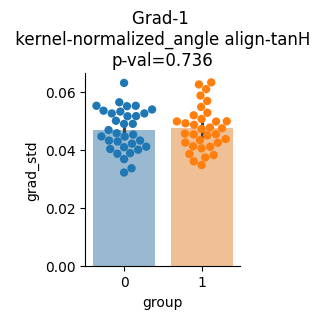

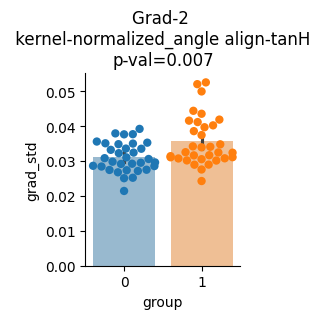

In [15]:
from scipy.stats import normaltest, ttest_ind, mannwhitneyu
import seaborn as sns

alpha = 0.05

for n_grad in [1,2]:
    y_var =  'grad_std'#'grad_minmaxdiff' #
    tmp = grad_stats.xs(n_grad, level='n_gradient')#.drop(64)

    figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
    sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
    sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
    _, pval_normal = normaltest(tmp[y_var])
    if pval_normal > alpha:
            print(f'{y_var} - normal distribution (fail to reject H0)')
            stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
    else: # non parametric test
            print(f'{y_var} - not normal distribution (reject H0)')    
            stats = mannwhitneyu(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0)
    axes.set(title=f'Grad-{n_grad} \n kernel-{kernel} align-{alignRef} \np-val={stats.pvalue:.3f}',
        ylabel=y_var, xlabel='group')#,ylim=[0,15])
    sns.despine()

## NPC

In [16]:
from utils import get_NPC_mask, get_basic_mask

nprf_r2 = get_NPC_mask()
mask, labeling_noParcel = get_basic_mask()

np.shape(nprf_r2)

(20484,)

In [17]:
n_grad = 2
g1 = np.array(gms_aligned[f'g{n_grad}']).T # n_vertices x n_subjects

# get the gradient loadings of the nodes of the ROI, for each subject (shape: number of nodes in network x N)
G1_net = g1[nprf_r2]

centroid_cog_net = np.nanmedian(G1_net, axis=0)  #np.median(G1_net, axis=0)  
dist_nodes_to_centroid = G1_net - centroid_cog_net  # shape: number of nodes in network x N

NPC_dispersion = np.nanmean((dist_nodes_to_centroid**2), axis = 0) 

df = pd.DataFrame(np.array([NPC_dispersion, centroid_cog_net]).T, index=sub_array, columns=['NPC_dispersion', 'NPC_centroid'])
df.index.name = 'subject'
df = df.join(group_list).set_index('group',append=True)
#df.to_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}_confspec-{confspec}.csv'))

df =  df.sort_index(level='subject')

In [18]:
# 2D dispersion measure
n_grad = 'both 2D'

g1 = np.array(gms_aligned[f'g1']).T
g2 = np.array(gms_aligned[f'g2']).T

G1_net = g1[nprf_r2]
G2_net = g2[nprf_r2]
G_net = np.stack([G1_net, G2_net], axis=-1)  # shape: number of nodes in network x N x 2

centroid_cog_net = np.nanmedian(G_net, axis=0)  # shape: N x 2

# Compute the 2D Euclidean distance between each node and the centroid for each subject
dist_nodes_to_centroid = G_net - centroid_cog_net  # shape: number of nodes in network x N x 2
squared_distances = np.sum(dist_nodes_to_centroid**2, axis=-1)  # sum squares across 2D (last axis), shape: number of nodes in network x N

# Compute the within-network dispersion as the mean squared distance
NPC_2d_dispersion =  np.nanmean(squared_distances, axis=0)  # shape: N

df = pd.DataFrame(NPC_2d_dispersion.T, index=sub_array, columns=['NPC_2D_dispersion'])
df.index.name = 'subject'
df = df.join(group_list).set_index('group',append=True)
#n_grad = 'both2D'
#df.to_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}_confspec-{confspec}.csv'))



NPC_2D_dispersion - not normal distribution (reject H0)
MannwhitneyuResult(statistic=313.0, pvalue=0.003051998009491109)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


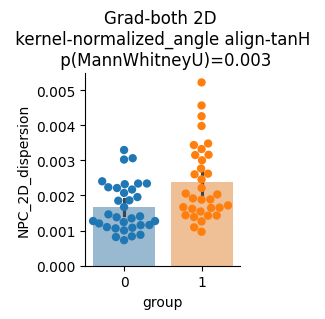

In [19]:
y_var = 'NPC_2D_dispersion' if n_grad == 'both 2D' else 'NPC_dispersion' # #  'NPC_centroid' # 
#df.loc[df[y_var].idxmax()]
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import normaltest
alpha = 0.05 # threshold for normality

y_var = 'NPC_2D_dispersion' if n_grad == 'both 2D' else 'NPC_dispersion' # #  'NPC_centroid' # 

#max_index = df[y_var].idxmax() # sub-06 weird... 
#tmp = df.drop(index=max_index)
#tmp = tmp.drop(index=tmp[y_var].idxmax())
#tmp = tmp.drop(index=tmp[y_var].idxmax())
tmp = df.copy()

figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])
if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
        test_name = 't-test'
else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0)
        test_name = 'MannWhitneyU'
axes.set(title=f'Grad-{n_grad} \n kernel-{kernel} align-{alignRef} \n p({test_name})={stats.pvalue:.3f}',ylabel=y_var, xlabel='group') #,ylim=[0,30])
sns.despine()

print(stats)

## Mean eccentricity  of different networks ?!

take the mean eccentricity of the network anchors: visual, somato-motot & default!

In [20]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , labeling_glasser, mask=mask_glasser) #, fill=np.nan) #grad_sub[n_grad-1]

atlas_spec = 'CAatlas'

In [21]:
fn_target_labels_caNets = op.join(bids_folder,'derivatives','networks_infomap_full', f'sub-average_consensusMapping_confspec-36Pscrub3BPfilter.npy') # mapped to ColeAnticevic nets
caNets_fsav5_mapping = np.load(fn_target_labels_caNets)

atlas_spec = 'own_av_netAtlas'

In [22]:
nets_of_interest = [2, 3, 9]  # visual, somato-motor, default

df_eccentricities = []

for n_network in nets_of_interest:
    net_mask = np.where(caNets_fsav5_mapping == (n_network))[0]
    g1 = np.array(gms_aligned[f'g1']).T[net_mask]
    g2 = np.array(gms_aligned[f'g2']).T[net_mask]
    g3 = np.array(gms_aligned[f'g3']).T[net_mask]

    eccentricities = np.sqrt(g1**2 + g2**2) # + g3**2)
    df_eccentricities.append(pd.DataFrame(np.nanmean(eccentricities, axis=0), index=sub_array, columns=[CAatlas_names.loc[n_network]['Network Name']]))
 
df_eccentricities = pd.concat(df_eccentricities, axis=1)
df_eccentricities.index.name = 'subject'
df_eccentricities = df_eccentricities.join(group_list, on='subject').set_index('group',append=True)


Visual2 - normal distribution (fail to reject H0)
TtestResult(statistic=-1.6115557035339538, pvalue=0.11231245213061314, df=59.939784474945135)
Somatomotor - normal distribution (fail to reject H0)
TtestResult(statistic=-1.8045327957888155, pvalue=0.07602692825947326, df=61.72134722905752)
Default - normal distribution (fail to reject H0)
TtestResult(statistic=-1.6871421538253615, pvalue=0.09657499125529577, df=62.330132894839274)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


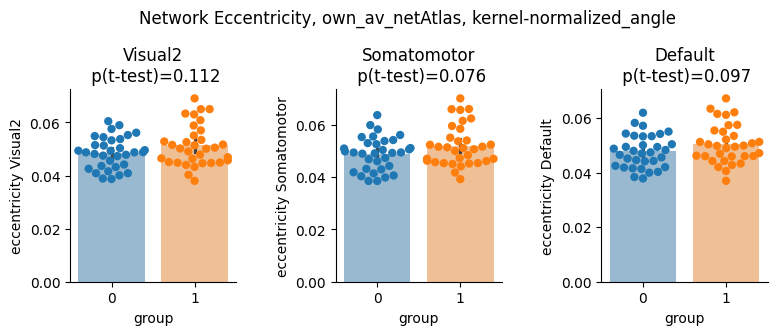

In [23]:
tmp = df_eccentricities.copy()

fig, axs = plt.subplots(1,3, figsize=(3*3, 2.5))
for i, y_var in enumerate(df_eccentricities.columns):
        axes = axs[i]
        sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False, ax=axes)
        sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False, ax=axes)
        _, pval_normal = normaltest(tmp[y_var])
        if pval_normal > alpha:
                print(f'{y_var} - normal distribution (fail to reject H0)')
                stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
                test_name = 't-test'
        else: # non parametric test
                print(f'{y_var} - not normal distribution (reject H0)')    
                stats = mannwhitneyu(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0)
                test_name = 'MannWhitneyU'
        axes.set(title=f'{y_var}\n p({test_name})={stats.pvalue:.3f}',ylabel=f'eccentricity {y_var}', xlabel='group') #,ylim=[0,30])
        sns.despine()

        print(stats)

fig.suptitle(f'Network Eccentricity, {atlas_spec}, kernel-{kernel}', y=1.2)
plt.subplots_adjust(wspace=0.6)